In [2]:
import pandas as pd
from datasets import load_dataset

ds = load_dataset("google/code_x_glue_cc_defect_detection")

In [3]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 21854
    })
    validation: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
    test: Dataset({
        features: ['id', 'func', 'target', 'project', 'commit_id'],
        num_rows: 2732
    })
})


In [4]:
train_df=ds['train'].to_pandas()
test_df=ds['test'].to_pandas()
val_df=ds['validation'].to_pandas()



In [9]:
import os
if not os.path.exists('results'):
    os.makedirs('results')

In [6]:
print(train_df.shape)
print(train_df.head(3))
print(train_df['target'].value_counts)

(21854, 5)
   id                                               func  target project  \
0   0  static av_cold int vdadec_init(AVCodecContext ...   False  FFmpeg   
1   1  static int transcode(AVFormatContext **output_...   False  FFmpeg   
2   2  static void v4l2_free_buffer(void *opaque, uin...   False  FFmpeg   

                                  commit_id  
0  973b1a6b9070e2bf17d17568cbaf4043ce931f51  
1  321b2a9ded0468670b7678b7c098886930ae16b2  
2  5d5de3eba4c7890c2e8077f5b4ae569671d11cf8  
<bound method IndexOpsMixin.value_counts of 0        False
1        False
2        False
3        False
4         True
         ...  
21849    False
21850    False
21851    False
21852    False
21853    False
Name: target, Length: 21854, dtype: bool>


static int r3d_read_rdvo(AVFormatContext *s, Atom *atom)

{

    R3DContext *r3d = s->priv_data;

    AVStream *st = s->streams[0];

    int i;



    r3d->video_offsets_count = (atom->size - 8) / 4;

    r3d->video_offsets = av_malloc(atom->size);

    if (!r3d->video_offsets)

        return AVERROR(ENOMEM);



    for (i = 0; i < r3d->video_offsets_count; i++) {

        r3d->video_offsets[i] = avio_rb32(s->pb);

        if (!r3d->video_offsets[i]) {

            r3d->video_offsets_count = i;


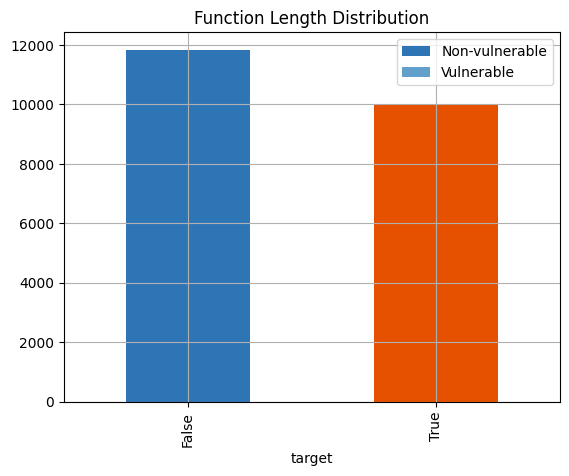

In [11]:
import matplotlib.pyplot as plt
# 1. Label distribution
train_df['target'].value_counts().plot(kind='bar', color=['#2E75B6','#E65100'])
plt.title('Label Distribution (0=Safe, 1=Vulnerable)')
plt.savefig('results/label_dist.png', dpi=150)
# 2. Function length (proxy for complexity)
train_df['func_len'] = train_df['func'].apply(len)
train_df.groupby('target')['func_len'].hist(alpha=0.7, bins=50)
plt.legend(['Non-vulnerable', 'Vulnerable'])
plt.title('Function Length Distribution')
plt.savefig('results/length_dist.png', dpi=150)
# 3. Sample a vulnerable function
vuln_sample = train_df[train_df['target']==1].iloc[0]['func']
print(vuln_sample[:500])

In [14]:
import os
if not os.path.exists('data/processed'):
    os.makedirs('data/processed')

train_df.to_csv('data/processed/train.csv', index=False)
val_df.to_csv('data/processed/val.csv',   index=False)
test_df.to_csv('data/processed/test.csv',  index=False)
print('Datasets saved.')

Datasets saved.


In [15]:
# Create a zip archive of the results and processed data
!zip -r saved_files.zip results/ data/processed/

  adding: results/ (stored 0%)
  adding: results/label_dist.png (deflated 25%)
  adding: results/length_dist.png (deflated 24%)
  adding: data/processed/ (stored 0%)
  adding: data/processed/test.csv (deflated 74%)
  adding: data/processed/train.csv (deflated 75%)
  adding: data/processed/val.csv (deflated 74%)


In [16]:
# Download the zip file
from google.colab import files
files.download('saved_files.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>